# Final Project Report

#### Done by: Lindsay Aviles

In [199]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

Text(0, 0.5, 'Radial Velocity')

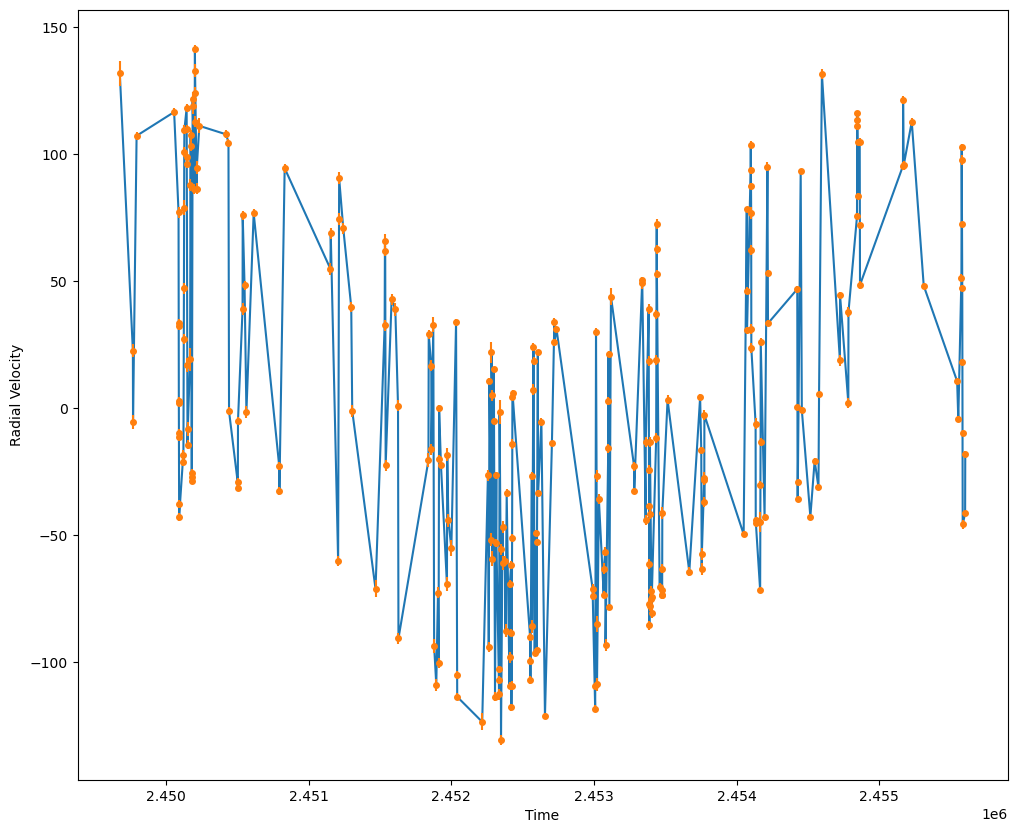

In [200]:
data_array = np.loadtxt("final_data.txt", skiprows=22)
hjd = data_array[:,0]
radial_V = data_array[:,1]
radial_err = data_array[:,2]



plt.figure(figsize=(12,10))
plt.plot(hjd, radial_V)



plt.errorbar(hjd,radial_V,yerr=radial_err, marker = "o", markersize = 4, linestyle="")
plt.xlabel("Time")
plt.ylabel("Radial Velocity")


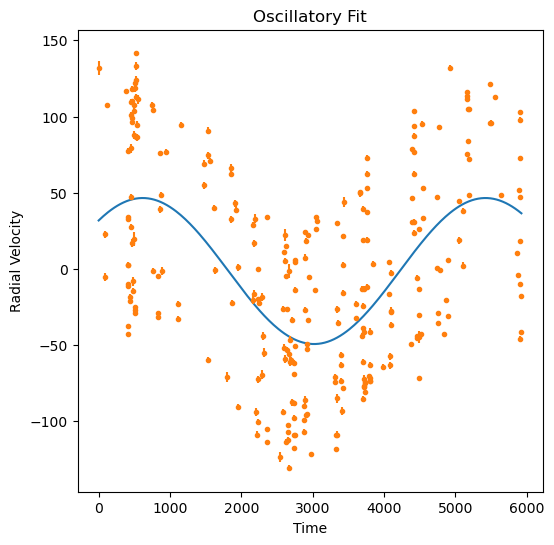

<Figure size 640x480 with 0 Axes>

In [238]:
x = hjd - hjd[0]
y = radial_V
y_err = radial_err


def model(x, a, b, c, d):
    return  a * np.sin(2.0 * np.pi * (x-b)/c) + d

params, params_cov = optimize.curve_fit(model, x, y, sigma = y_err, p0 = [70, 0, 5000, 0])

a, b, c, d = params
x_fit = np.linspace(min(x), max(x), 274)
y_fit = model(x_fit, a, b, c, d)

f = plt.figure(figsize=(6,6))

plt.plot(x_fit, y_fit, label = "Oscillatory Fit")
plt.errorbar(x,y, y_err, fmt= 'o', markersize= 3)
plt.xlabel("Time")
plt.ylabel("Radial Velocity")
plt.title("Oscillatory Fit")
plt.show()
plt.savefig("fit.png")

Standard Deviation: 68.4271015473797
Expirimental Error: 1.8060667343065693


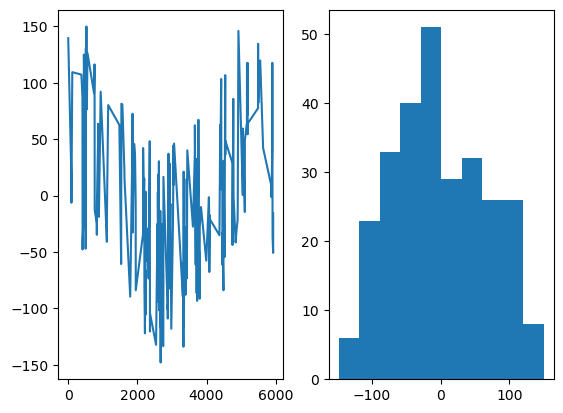

<Figure size 600x600 with 0 Axes>

In [234]:
fig, axes = plt.subplots(1,2)
residuals = radial_V - y_fit 
plt.figure(figsize=(6,6))
axes[0].plot(x,residuals, label = "residuals")

deviation = np.std(residuals)
expirimental_err = np.mean(y_err)
axes[1].hist(residuals, bins= 10, label = "residuals histogram")
print("Standard Deviation:", deviation)
print("Expirimental Error:", expirimental_err)


In [239]:
k = abs(a)
p = abs(c)

mass_s = 0.905
print(k)
print(p)
mass_e = (k/28.4)* (p/365)**(1/3) * (mass_s)**(2/3)
print(mass_e)

47.917711161926526
4807.040700060243
3.727964399475667


#### The Star 55 Cnc has a mass of 0.905 times the mass of the sun, and the exoplanet 55 Cnc C has an amplitude K = 16.83 and a period of P = 40.03 days, which means the exoplanet 55 Cnc C is 0.265 times the mass of Jupiter.<br> <br> The star 55 Cnc has a mass 0.905 times the mass of the sun, and the exoplanet 55 Cnc d has an amplitude of K = 47.92 and a period of P= 4807.05, which means the exoplanet 55 Cnc d is 3.728 times the mass of Jupiter. 